# 01.08 - Faster R-CNN ResNet50-FPN V2 experimental lab

**Notebook type:** Practice notebook with theory, six linked exercises, smoke checks, and an optional full benchmark.

**Daily output:** A reproducible baseline-versus-tuned Faster R-CNN experiment with loss curves, class-wise metrics, mAP50/mAP75, a confidence-threshold sweep, and written error analysis.

The original version used two 64×64 images, one object per image, and one update. That was useful for checking Torchvision's API, but it could not answer an accuracy question. This expanded lab deliberately goes beyond the original masterplan: it creates **144 training and 48 untouched validation images** at 160×160, with three shape classes, 0–6 objects, small objects, clutter, blur, occlusion, overlapping colors, empty images, and a harder validation distribution.

## What makes this a real experiment?

Faster R-CNN has two learned stages. The Region Proposal Network (RPN) tests anchors at every FPN level, removes redundant proposals with NMS, and forwards promising regions. ROI heads then classify and refine those proposals. Accuracy can fail for different reasons:

- **Missed small objects:** anchors are too large, resolution is too low, or too few RPN proposals survive.
- **Duplicate/false detections:** RPN or box NMS is too permissive, or the score threshold is too low.
- **Poor localization:** box-regression loss remains high; AP75 lags AP50.
- **Poor classification:** classification loss remains high; visually similar classes are confused.
- **Overfitting:** training loss falls while untouched validation mAP stalls.

Change one factor at a time. Hold the split, seed, initialization, batch size, and epochs constant for a fair comparison. AP summarizes a full score ranking; F1 describes one chosen operating threshold. They answer different questions.

## Strict offline and random-initialization policy

This notebook uses only the standard library and already-installed course libraries. It requires no package installation or network access. Every detector is constructed with both `weights=None` and `weights_backbone=None`; no checkpoint enum is imported, no model file is downloaded, and the ResNet50 backbone, FPN, RPN, and ROI heads all learn from random initialization on this dataset.

- The one-batch smoke run verifies code only.
- The full lab is opt-in with `RUN_FULL_EXPERIMENTS = True`.
- Random initialization needs substantially more optimization than transfer learning; the supplied full configuration uses 30 epochs.
- Use a CUDA machine for the full comparison. On CPU, use `max_train_batches` only while debugging; truncated training is not accuracy evidence.
- Because ResNet50-FPN V2 is large for 144 training images, watch validation mAP for overfitting and treat dataset size, regularization, and augmentation as experimental variables.

In [2]:
import csv
import json
import os
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFilter
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import tv_tensors
from torchvision.io import decode_image
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.ops import box_iou
from torchvision.transforms import v2

SEED = 1
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = {1: "striped_rectangle", 2: "ring", 3: "marked_triangle"}
NUM_CLASSES = 1 + len(CLASS_NAMES)
LOSS_NAMES = ("loss_classifier", "loss_box_reg", "loss_objectness", "loss_rpn_box_reg")
print("device:", DEVICE)

device: cpu


## Prepared Image Data

The generator is provided because data creation is not an exercise. It writes PNG files plus one manifest row per image. Validation is intentionally harder and is never augmented or sampled into training.

**Return structure — `generate_detection_benchmark`:** A `dict` with `data_dir` (`str`), `manifest_path` (`str`), `train_images` (`int`), `val_images` (`int`), and `class_support` (`dict[int, int]`). Its side effects are 192 RGB PNG files `[H,W,3]` and `_day01_detection_data/manifest.csv`. Each CSV row stores a unique integer `image_id`, `split`, relative `image_path`, integer dimensions and difficulty flags, `boxes` as JSON `list[list[float]]` in `[x1,y1,x2,y2]` order, and `labels` as a same-length JSON `list[int]`. Empty images use empty lists.

In [3]:
DATA_DIR = "_day01_detection_data"
IMAGE_DIR = os.path.join(DATA_DIR, "images")
MANIFEST_PATH = os.path.join(DATA_DIR, "manifest.csv")


def generate_detection_benchmark(
    train_images=144,
    val_images=48,
    image_size=160,
    seed=SEED,
):
    os.makedirs(IMAGE_DIR, exist_ok=True)
    rng = np.random.default_rng(seed)
    rows = []
    class_support = {1: 0, 2: 0, 3: 0}

    for split, count in (("train", train_images), ("val", val_images)):
        for local_index in range(count):
            image_id = len(rows)
            difficult = int(rng.random() < (0.35 if split == "train" else 0.70))

            yy, xx = np.mgrid[0:image_size, 0:image_size]
            base = rng.integers(45, 170, size=3).astype(np.float32)
            slope_x = rng.uniform(-35, 35, size=3)
            slope_y = rng.uniform(-35, 35, size=3)
            background = (
                base[None, None, :]
                + xx[:, :, None] * slope_x[None, None, :] / image_size
                + yy[:, :, None] * slope_y[None, None, :] / image_size
                + rng.normal(0, 10 + 5 * difficult, size=(image_size, image_size, 3))
            )
            image = Image.fromarray(np.clip(background, 0, 255).astype(np.uint8), mode="RGB")
            draw = ImageDraw.Draw(image)

            # Unlabelled clutter prevents a trivial foreground/background shortcut.
            for _ in range(10 + 8 * difficult):
                x1 = int(rng.integers(0, image_size - 4))
                y1 = int(rng.integers(0, image_size - 4))
                x2 = min(image_size - 1, x1 + int(rng.integers(3, 22)))
                y2 = min(image_size - 1, y1 + int(rng.integers(2, 12)))
                color = tuple(int(v) for v in rng.integers(30, 225, size=3))
                if rng.random() < 0.5:
                    draw.line((x1, y1, x2, y2), fill=color, width=int(rng.integers(1, 4)))
                else:
                    draw.rectangle((x1, y1, x2, y2), outline=color, width=1)

            empty_probability = 0.08 if split == "train" else 0.12
            if rng.random() < empty_probability:
                object_count = 0
            else:
                upper = 5 if split == "train" else 6
                object_count = int(rng.integers(1, upper + 1))

            boxes = []
            labels = []
            for _ in range(object_count):
                label = int(rng.integers(1, 4))
                min_side = 12 if split == "train" else 8
                max_side = 54 if split == "train" else 48
                width = int(rng.integers(min_side, max_side + 1))
                height = int(rng.integers(min_side, max_side + 1))
                if label == 1:
                    width = min(max_side + 12, int(width * rng.uniform(1.2, 1.8)))
                elif label == 3:
                    height = min(max_side + 12, int(height * rng.uniform(1.15, 1.65)))
                x1 = int(rng.integers(2, max(3, image_size - width - 2)))
                y1 = int(rng.integers(2, max(3, image_size - height - 2)))
                x2 = min(image_size - 2, x1 + width)
                y2 = min(image_size - 2, y1 + height)

                palette = np.array(
                    [[220, 75, 70], [70, 190, 110], [70, 125, 225], [220, 180, 65], [175, 85, 205]],
                    dtype=np.int64,
                )
                fill_array = palette[int(rng.integers(0, len(palette)))].copy()
                fill_array += rng.integers(-28, 29, size=3)
                fill = tuple(int(v) for v in np.clip(fill_array, 20, 235))
                outline = tuple(int(v) for v in np.clip(255 - fill_array, 20, 235))

                if label == 1:  # striped rectangle
                    draw.rectangle((x1, y1, x2, y2), fill=fill, outline=outline, width=2)
                    for stripe_x in range(x1 + 4, x2, 7):
                        draw.line((stripe_x, y1 + 2, min(x2 - 1, stripe_x + 5), y2 - 2), fill=outline, width=1)
                elif label == 2:  # ring
                    draw.ellipse((x1, y1, x2, y2), fill=fill, outline=outline, width=2)
                    inset = max(3, min(width, height) // 4)
                    draw.ellipse((x1 + inset, y1 + inset, x2 - inset, y2 - inset), outline=outline, width=2)
                else:  # triangle with center mark
                    points = ((x1 + width // 2, y1), (x1, y2), (x2, y2))
                    draw.polygon(points, fill=fill, outline=outline)
                    center_x = x1 + width // 2
                    center_y = y1 + int(height * 0.62)
                    radius = max(1, min(width, height) // 10)
                    draw.ellipse((center_x - radius, center_y - radius, center_x + radius, center_y + radius), fill=outline)

                boxes.append([float(x1), float(y1), float(x2), float(y2)])
                labels.append(label)
                class_support[label] += 1

                # Partial occlusion is more common in validation, creating a real shift.
                if rng.random() < (0.18 if split == "train" else 0.38):
                    occ_width = max(3, int(width * rng.uniform(0.15, 0.40)))
                    occ_x1 = int(rng.integers(x1, max(x1 + 1, x2 - occ_width + 1)))
                    occ_color = tuple(int(v) for v in rng.integers(35, 210, size=3))
                    draw.rectangle((occ_x1, y1, min(x2, occ_x1 + occ_width), y2), fill=occ_color)

            if difficult and rng.random() < 0.65:
                image = image.filter(ImageFilter.GaussianBlur(radius=float(rng.uniform(0.4, 1.2))))

            filename = f"{split}_{local_index:03d}.png"
            relative_path = os.path.join(DATA_DIR, "images", filename)
            image.save(relative_path)
            rows.append(
                {
                    "image_id": image_id,
                    "split": split,
                    "image_path": relative_path,
                    "width": image_size,
                    "height": image_size,
                    "is_empty": int(object_count == 0),
                    "difficulty": difficult,
                    "boxes": json.dumps(boxes),
                    "labels": json.dumps(labels),
                }
            )

    columns = ["image_id", "split", "image_path", "width", "height", "is_empty", "difficulty", "boxes", "labels"]
    with open(MANIFEST_PATH, "w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=columns)
        writer.writeheader()
        writer.writerows(rows)

    return {
        "data_dir": DATA_DIR,
        "manifest_path": MANIFEST_PATH,
        "train_images": train_images,
        "val_images": val_images,
        "class_support": class_support,
    }


prepared = generate_detection_benchmark()
print("prepared:", prepared)


C:\Users\Dell\AppData\Local\Temp\ipykernel_13924\427390483.py:32: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(np.clip(background, 0, 255).astype(np.uint8), mode="RGB")


prepared: {'data_dir': '_day01_detection_data', 'manifest_path': '_day01_detection_data\\manifest.csv', 'train_images': 144, 'val_images': 48, 'class_support': {1: 182, 2: 184, 3: 186}}


### Inspect the challenge

The grid below uses manifest annotations, not model predictions. Look for clutter that resembles edges, overlapping colors across classes, partial occlusion, small instances, and images with multiple scales.

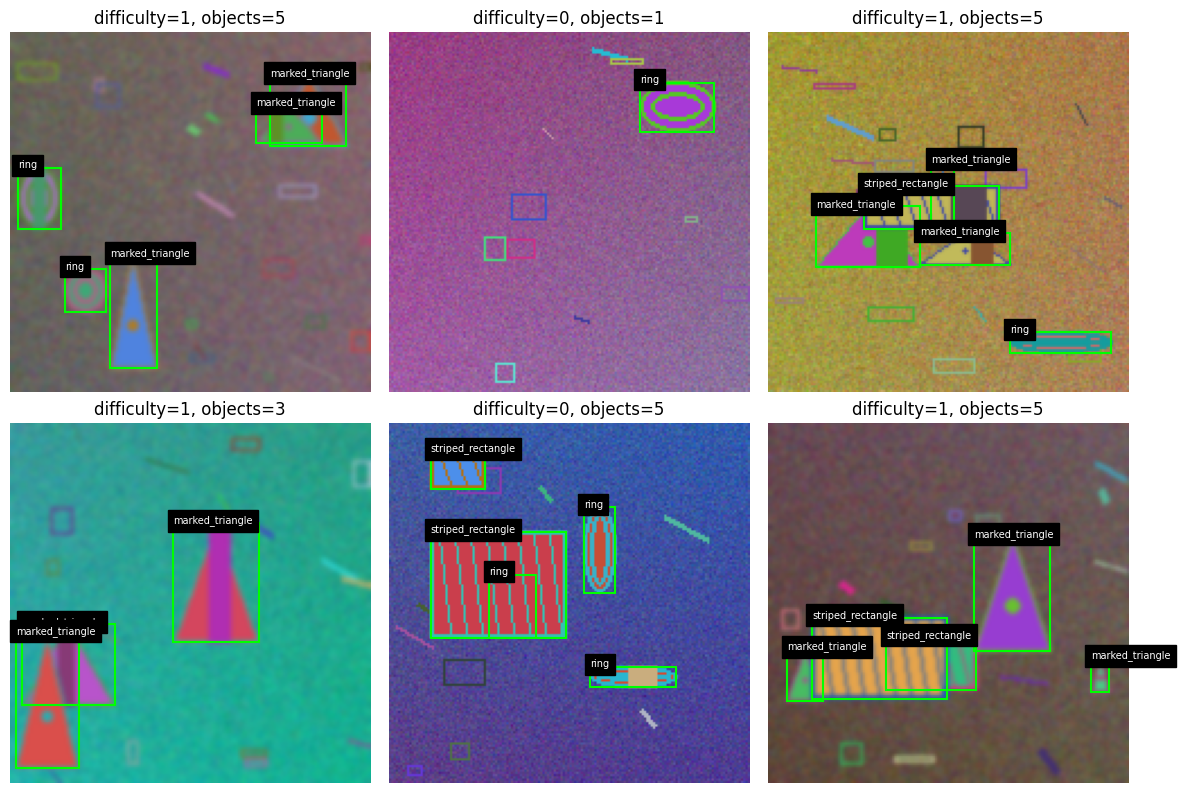

,split,images,empty_images,striped_rectangle,ring,marked_triangle
0,train,144,13,128,136,127
1,val,48,3,54,48,59


In [4]:
manifest_frame = pd.read_csv(MANIFEST_PATH)
validation_examples = manifest_frame[(manifest_frame["split"] == "val") & (manifest_frame["is_empty"] == 0)].head(6)
figure, axes = plt.subplots(2, 3, figsize=(12, 8))
for axis, (_, row) in zip(axes.reshape(-1), validation_examples.iterrows()):
    image = Image.open(row["image_path"]).convert("RGB")
    axis.imshow(image)
    for box, label in zip(json.loads(row["boxes"]), json.loads(row["labels"])):
        x1, y1, x2, y2 = box
        axis.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color="lime", linewidth=1.5))
        axis.text(x1, y1, CLASS_NAMES[label], color="white", fontsize=7, backgroundcolor="black")
    axis.set_title(f"difficulty={int(row['difficulty'])}, objects={len(json.loads(row['labels']))}")
    axis.axis("off")
plt.tight_layout()
plt.show()

support_rows = []
for split in ("train", "val"):
    split_frame = manifest_frame[manifest_frame["split"] == split]
    labels = [label for text in split_frame["labels"] for label in json.loads(text)]
    support_rows.append({"split": split, "images": len(split_frame), "empty_images": int(split_frame["is_empty"].sum()), **{CLASS_NAMES[c]: labels.count(c) for c in CLASS_NAMES}})
display(pd.DataFrame(support_rows))

## Exercise 01-A: File-backed dataset and box-safe augmentation

Implement a custom dataset with Torchvision's built-in `transforms.v2`. Wrap boxes as `tv_tensors.BoundingBoxes` so `RandomHorizontalFlip` updates the image and its boxes together; use `ColorJitter`, `ToDtype`, and `ToPureTensor` instead of reimplementing those operations. Never augment validation data.

**Return structure — `DetectionDataset`:** A callable `torch.utils.data.Dataset`. `len(dataset)` returns an `int`. `dataset[i]` returns `(image, target)`: `image` is a CPU `float32` tensor `[3,H,W]` in `[0,1]`; `target` is a dictionary containing `boxes` (`float32 [K,4]`), `labels` (`int64 [K]`), `image_id` (`int64 [1]`), `area` (`float32 [K]`), `iscrowd` (`int64 [K]`, all zero), and scalar `difficulty` (`int64`). `K` may be zero.

**Return structure — `collate_detection_batch`:** A tuple of two Python lists `(images, targets)`, each of length batch size. Items preserve the dataset structures because detection images can have different sizes and object counts.

In [9]:
# TODO 01-A
class DetectionDataset(Dataset):
    def __init__(self, manifest_path, split, hflip_probability=0.0, color_jitter=0.0):
        df = pd.read_csv(manifest_path)
        self.rows = []
        for idx, row in df.iterrows() :
            if row["split"] != split : continue
            self.rows.append(row)
        self.split = split
        self.transforms = v2.Compose([
            v2.RandomHorizontalFlip(p = hflip_probability),
            v2.ColorJitter(brightness = color_jitter, contrast = color_jitter, saturation = color_jitter), 
            v2.ToDtype(dtype = torch.float32, scale = True),
            v2.ToPureTensor()
        ])

    def __len__(self):
        return len(self.rows)
    
    def __getitem__(self, index):
        item = self.rows[index]
        image = tv_tensors.Image(decode_image(item["image_path"], mode = "RGB"))
        boxes = tv_tensors.BoundingBoxes(
            torch.tensor(json.loads(item["boxes"]), dtype = torch.float32).reshape(-1,4),
            format = "XYXY",
            canvas_size = image.shape[-2:]
        )
        image, boxes = self.transforms(image,boxes)
        labels = torch.tensor(json.loads(item["labels"]), dtype = torch.int64)
        area = (boxes[:,3] - boxes[:,1]).clamp(min = 0) * (boxes[:,2] - boxes[:,0]).clamp(min = 0)
        return (image,{
            "boxes" : boxes,
            "labels" : labels,
            "image_id" : torch.tensor(item["image_id"],dtype = torch.int64),
            "area" : area,
            "iscrowd" : torch.zeros(len(boxes), dtype = torch.int64),
            "difficulty" : torch.tensor(int(item["difficulty"]), dtype=torch.int64)
        })



def collate_detection_batch(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)


# Smoke check: load normal, difficult, and possibly empty samples through the real file boundary.
train_dataset = DetectionDataset(MANIFEST_PATH, "train", hflip_probability=0.5, color_jitter=0.15)
val_dataset = DetectionDataset(MANIFEST_PATH, "val")
smoke_images, smoke_targets = collate_detection_batch([train_dataset[0], train_dataset[1]])
print(len(train_dataset), len(val_dataset), smoke_images[0].shape, smoke_targets[0]["boxes"].shape)


144 48 torch.Size([3, 160, 160]) torch.Size([1, 4])


## Exercise 01-B: A configuration surface that matters

Build the exact official `fasterrcnn_resnet50_fpn_v2` with `weights=None`, `weights_backbone=None`, and `num_classes=4`. These arguments are fixed rather than configurable: every experiment must train the complete detector from random initialization without a download.

The default FPN anchor sizes `(32,64,128,256,512)` are intentionally contrasted with `(8,16,32,64,128)`, which better covers this dataset's small objects. Keep exactly one size and three aspect ratios per FPN level so the existing V2 RPN head remains compatible.

**Return structure — `build_configurable_detector`:** A Torchvision `FasterRCNN` module on `device`, constructed with both weight arguments set to `None` and a randomly initialized four-class predictor. In training mode, calling it with `list[float32 Tensor[C,H,W]]` and `list[target dict]` returns a dictionary of four scalar loss tensors: `loss_classifier`, `loss_box_reg`, `loss_objectness`, and `loss_rpn_box_reg`. In evaluation mode, calling it with only the image list returns `list[dict]`; each dictionary has `boxes` (`float32 [P,4]`), `labels` (`int64 [P]`), and `scores` (`float32 [P]`) on the model device.

In [10]:
SMOKE_CONFIG = {
    "image_size": 160,
    "anchor_sizes": (8, 16, 32, 64, 128),
    "aspect_ratios": (0.5, 1.0, 2.0),
    "rpn_pre_nms_train": 400,
    "rpn_post_nms_train": 200,
    "rpn_pre_nms_test": 200,
    "rpn_post_nms_test": 100,
    "rpn_nms_threshold": 0.70,
    "model_score_floor": 0.01,
    "box_nms_threshold": 0.50,
    "detections_per_image": 60,
}

In [31]:
# TODO 01-B
def build_configurable_detector(config, num_classes=NUM_CLASSES, device=DEVICE):
    torch.manual_seed(SEED)
    model = fasterrcnn_resnet50_fpn_v2(
        weights = None,
        num_classes = num_classes,
        min_size = config["image_size"],
        max_size = config["image_size"],
        rpn_pre_nms_top_n_train = config["rpn_pre_nms_train"],
        rpn_pre_nms_top_n_test = config["rpn_pre_nms_test"],
        rpn_post_nms_top_n_train = config["rpn_post_nms_train"],
        rpn_post_nms_top_n_test = config["rpn_post_nms_test"],
        rpn_nms_threshold = config["rpn_nms_threshold"],
        box_score_thresh = config["model_score_floor"],
        box_nms_threshold = config["box_nms_threshold"],
        box_detections_per_image = config["detections_per_image"]
    )
    sizes = tuple(tuple([i]) for i in config["anchor_sizes"])
    ratios = (tuple(tuple([i]) for i in config["aspect_ratios"]),) * len(sizes)
    model.rpn.anchor_generator = AnchorGenerator(sizes = sizes, aspect_ratios = ratios)
    return model.to(device)

# Smoke check: both weight sources must be fixed to None inside the builder.
smoke_model = build_configurable_detector(SMOKE_CONFIG)
print(type(smoke_model).__name__, smoke_model.transform.min_size, smoke_model.rpn._post_nms_top_n)

FasterRCNN (160,) {'training': 200, 'testing': 100}


## Exercise 01-C: Multi-epoch training with controlled settings

Sum all four losses, reject non-finite totals, and record component means. `max_batches` is only a debugging control; compare accuracy configurations with the complete training split.

**Return structure — `train_one_epoch`:** A `dict[str, float|int]` with each name in `LOSS_NAMES`, `total`, `batches`, and `runtime_seconds`. Loss values are means over processed batches. The supplied model and optimizer are updated.

**Return structure — `fit_detector`:** A `list[dict]` of length `epochs`, ordered by epoch. Each dictionary contains the `train_one_epoch` fields plus one-based `epoch` (`int`) and the learning rate used in that epoch (`float`). The supplied model is updated in place.

In [32]:
# TODO 01-C
def train_one_epoch(model, loader, optimizer, device=DEVICE, max_batches=None, gradient_clip_norm=None):
    model.train()
    loss_name = ["loss_classifier", "loss_box_reg", "loss_objectness", "loss_rpn_box_reg"]
    total_loss = {name : 0.0 for name in loss_name}
    total_loss["total"] = 0.0
    batch_count = 0
    started = time.perf_counter()
    if max_batches == 0 :
        raise ValueError()
    for images, targets in loader :
        images = [image.to(device) for image in images]
        targets = [{key : value.to(device) for key, value in target.items()} for target in targets]

        optimizer.zero_grad()
        loss = model(images,targets)
        total_losses = sum(loss.values())

        total_losses.backward()
        if gradient_clip_norm is not None : 
            torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm = gradient_clip_norm)
        optimizer.step()

        batch_count += 1
        for name in loss_name :
            total_loss[name] += loss[name].item()
        total_loss["total"] += total_losses.item()
        if(batch_count == max_batches) : break
    record = {key : value for key, value in total_loss.items()}
    record["batches"] = batch_count
    record["runtime_seconds"] = time.perf_counter() - started
    return record


def fit_detector(
    model,
    train_loader,
    epochs,
    optimizer_name="sgd",
    learning_rate=0.005,
    weight_decay=0.0005,
    momentum=0.9,
    scheduler_step=3,
    scheduler_gamma=0.2,
    gradient_clip_norm=None,
    max_batches=None,
    device=DEVICE,
):
    if optimizer_name == "sgd" : 
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr = learning_rate,
            weight_decay = weight_decay,
            momentum = momentum
        )
    else :
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr = learning_rate,
            weight_decay = weight_decay
        )
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer = optimizer,
        step_size = scheduler_step,
        gamma = scheduler_gamma,
    )
    histories = []
    for epoch in range(epochs) :
        history = train_one_epoch(model,train_loader,optimizer,device,max_batches,gradient_clip_norm)
        history["epoch"] = epoch + 1
        history["lr"] = optimizer.param_groups[0]["lr"]
        histories.append(history)
        scheduler.step()
    return histories


# Smoke check: one genuine forward/backward update on file-backed images.
smoke_loader = DataLoader(Subset(train_dataset, [0, 1]), batch_size=2, shuffle=False, collate_fn=collate_detection_batch)
smoke_history = fit_detector(smoke_model, smoke_loader, epochs=1, learning_rate=0.001, max_batches=1)
print("smoke training:", smoke_history[-1])


smoke training: {'loss_classifier': 1.5032360553741455, 'loss_box_reg': 0.0015608154935762286, 'loss_objectness': 0.6919527053833008, 'loss_rpn_box_reg': 0.001880073337815702, 'total': 2.198629856109619, 'batches': 1, 'runtime_seconds': 1.713363999966532, 'epoch': 1, 'lr': 0.001}


## Exercise 01-D: Cache full validation predictions

Inference is expensive; threshold sweeps are not. Run the model once and keep raw predictions on CPU. The model's internal score floor must be lower than every threshold you intend to test.

**Return structure — `predict_dataset`:** A tuple `(records, seconds_per_image)`. `records` is a list with one dictionary per processed image. Each dictionary contains `image_id` and `difficulty` (`int`); `gt_boxes` and `boxes` (`CPU float32 [K,4]` and `[P,4]`); `gt_labels` and `labels` (`CPU int64 [K]` and `[P]`); and `scores` (`CPU float32 [P]`). `seconds_per_image` is a non-negative Python `float`.

In [ ]:
# TODO 01-D
def predict_dataset(model, loader, device=DEVICE, max_batches=None):
    raise NotImplementedError("Run inference and cache CPU predictions beside CPU ground truth")


# Smoke check: cache predictions once so many thresholds can be evaluated cheaply.
smoke_val_loader = DataLoader(Subset(val_dataset, [0, 1]), batch_size=2, shuffle=False, collate_fn=collate_detection_batch)
smoke_predictions, smoke_seconds_per_image = predict_dataset(smoke_model, smoke_val_loader)
print(len(smoke_predictions), "records; seconds/image:", round(smoke_seconds_per_image, 4))


## Exercise 01-E: Class-aware matching and detection metrics

Sort predictions by score within each class. A prediction is a true positive only if it reaches the IoU threshold and matches an as-yet-unmatched ground-truth box of the same class in the same image. Duplicate detections are false positives.

`mAP50` rewards finding and roughly localizing objects; `mAP75` demands tighter boxes. Macro-F1 gives all three classes equal weight at one score threshold. This educational evaluator is deterministic and dependency-light, but competition submissions should use the competition's official metric implementation.

**Return structure — `evaluate_predictions`:** A dictionary with numeric `score_threshold`, `iou_threshold`, `images`, `macro_precision`, `macro_recall`, `macro_f1`, `map`, `empty_images`, and `false_positives_on_empty`. `per_class` is a three-row `list[dict]`; each row contains `class_id`, `class_name`, `support`, `predictions`, `tp`, `fp`, `fn`, `precision`, `recall`, `f1`, and interpolated `ap`.

In [ ]:
# TODO 01-E
def evaluate_predictions(records, score_threshold=0.25, iou_threshold=0.50, num_classes=NUM_CLASSES):
    raise NotImplementedError("Perform class-aware one-to-one IoU matching and compute AP plus threshold metrics")


# Smoke check: compute real metrics even though a one-step random-weight model should score poorly.
smoke_metrics_50 = evaluate_predictions(smoke_predictions, score_threshold=0.20, iou_threshold=0.50)
smoke_metrics_75 = evaluate_predictions(smoke_predictions, score_threshold=0.20, iou_threshold=0.75)
display(pd.DataFrame(smoke_metrics_50["per_class"]))
print("smoke mAP50/mAP75:", smoke_metrics_50["map"], smoke_metrics_75["map"])


## Exercise 01-F: Choose an operating threshold

A score threshold is a deployment choice, not a learned weight. Sweep cached predictions, select a threshold using validation only, and report the precision/recall cost. Do not tune on test data.

**Return structure — `sweep_score_thresholds`:** A `list[dict]` with one row per input threshold, in the same order. Every row has Python floats `score_threshold`, `macro_precision`, `macro_recall`, and `macro_f1`, plus integer `false_positives_on_empty`.

In [ ]:
# TODO 01-F
def sweep_score_thresholds(records, thresholds, iou_threshold=0.50, num_classes=NUM_CLASSES):
    raise NotImplementedError("Reuse cached predictions and return one operating-point row per threshold")


# Smoke check: reuse cached outputs rather than rerunning the detector.
smoke_sweep = sweep_score_thresholds(smoke_predictions, [0.05, 0.20, 0.50])
display(pd.DataFrame(smoke_sweep))


## Full Experiment Lab: baseline vs small-object tuning

Set `RUN_FULL_EXPERIMENTS = True` when you are ready. Both configurations start from the same deterministic random initialization and use `weights=None`, `weights_backbone=None`, the same images, optimizer, learning rate, batch size, and epochs. The main changed variable is anchor scale; the tuned run also retains more test proposals to avoid starving small objects.

Start with the supplied comparison, then try one controlled change at a time:

1. `image_size`: 160 → 224 or 256 (accuracy/memory/latency tradeoff).
2. `learning_rate`: 0.001, 0.005, 0.01.
3. `optimizer_name`: SGD vs AdamW, with an appropriate learning-rate retune.
4. `hflip_probability` and `color_jitter`.
5. `anchor_sizes` and `aspect_ratios` after plotting your box size/aspect distribution.
6. RPN proposal counts and NMS thresholds.
7. Epoch count and scheduler timing.
8. More generated training images or stronger regularization if validation mAP diverges from training loss.

Do not claim a setting is better from training loss alone. Compare untouched validation mAP50, mAP75, macro-F1, per-class recall, false positives on empty images, and seconds per image.

In [ ]:
RUN_FULL_EXPERIMENTS = False

BASELINE_MODEL_CONFIG = {
    **SMOKE_CONFIG,
    "anchor_sizes": (32, 64, 128, 256, 512),
    "rpn_post_nms_test": 100,
}
TUNED_MODEL_CONFIG = {
    **SMOKE_CONFIG,
    "anchor_sizes": (8, 16, 32, 64, 128),
    "rpn_post_nms_test": 300,
}
TRAINING_CONFIG = {
    "epochs": 30,
    "optimizer_name": "sgd",
    "learning_rate": 0.005,
    "weight_decay": 0.0005,
    "momentum": 0.9,
    "scheduler_step": 20,
    "scheduler_gamma": 0.2,
    "gradient_clip_norm": 10.0,
    "max_train_batches": None,
    "batch_size": 4,
    "hflip_probability": 0.5,
    "color_jitter": 0.15,
}

experiment_specs = [
    {"name": "baseline_default_anchors", "model": BASELINE_MODEL_CONFIG},
    {"name": "tuned_small_object_anchors", "model": TUNED_MODEL_CONFIG},
]
experiment_rows = []
experiment_artifacts = {}

if RUN_FULL_EXPERIMENTS:
    for specification in experiment_specs:
        print("\nRUNNING", specification["name"])
        torch.manual_seed(SEED)
        training_dataset = DetectionDataset(
            MANIFEST_PATH,
            "train",
            hflip_probability=TRAINING_CONFIG["hflip_probability"],
            color_jitter=TRAINING_CONFIG["color_jitter"],
        )
        validation_dataset = DetectionDataset(MANIFEST_PATH, "val")
        training_loader = DataLoader(
            training_dataset,
            batch_size=TRAINING_CONFIG["batch_size"],
            shuffle=True,
            generator=torch.Generator().manual_seed(SEED),
            collate_fn=collate_detection_batch,
        )
        validation_loader = DataLoader(
            validation_dataset,
            batch_size=TRAINING_CONFIG["batch_size"],
            shuffle=False,
            collate_fn=collate_detection_batch,
        )

        experiment_model = build_configurable_detector(specification["model"])
        history = fit_detector(
            experiment_model,
            training_loader,
            epochs=TRAINING_CONFIG["epochs"],
            optimizer_name=TRAINING_CONFIG["optimizer_name"],
            learning_rate=TRAINING_CONFIG["learning_rate"],
            weight_decay=TRAINING_CONFIG["weight_decay"],
            momentum=TRAINING_CONFIG["momentum"],
            scheduler_step=TRAINING_CONFIG["scheduler_step"],
            scheduler_gamma=TRAINING_CONFIG["scheduler_gamma"],
            gradient_clip_norm=TRAINING_CONFIG["gradient_clip_norm"],
            max_batches=TRAINING_CONFIG["max_train_batches"],
        )
        predictions, seconds_per_image = predict_dataset(experiment_model, validation_loader)
        metrics_50 = evaluate_predictions(predictions, score_threshold=0.25, iou_threshold=0.50)
        metrics_75 = evaluate_predictions(predictions, score_threshold=0.25, iou_threshold=0.75)
        threshold_rows = sweep_score_thresholds(predictions, np.linspace(0.05, 0.80, 16))
        best_threshold = max(threshold_rows, key=lambda row: row["macro_f1"])
        experiment_rows.append(
            {
                "experiment": specification["name"],
                "train_images": len(training_dataset),
                "val_images": len(validation_dataset),
                "final_train_loss": history[-1]["total"],
                "mAP50": metrics_50["map"],
                "mAP75": metrics_75["map"],
                "macro_F1_at_0.25": metrics_50["macro_f1"],
                "best_threshold": best_threshold["score_threshold"],
                "best_macro_F1": best_threshold["macro_f1"],
                "empty_image_FPs_at_0.25": metrics_50["false_positives_on_empty"],
                "seconds_per_image": seconds_per_image,
            }
        )
        experiment_artifacts[specification["name"]] = {
            "history": history,
            "predictions": predictions,
            "metrics_50": metrics_50,
            "metrics_75": metrics_75,
            "threshold_sweep": threshold_rows,
        }
        del experiment_model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    display(pd.DataFrame(experiment_rows))
    for name, artifacts in experiment_artifacts.items():
        print("\n", name)
        display(pd.DataFrame(artifacts["metrics_50"]["per_class"]))
else:
    display(
        pd.DataFrame(
            [
                {
                    "experiment": item["name"],
                    "weights": "None",
                    "anchor_sizes": item["model"]["anchor_sizes"],
                    "test_proposals": item["model"]["rpn_post_nms_test"],
                    "epochs": TRAINING_CONFIG["epochs"],
                }
                for item in experiment_specs
            ]
        )
    )
    print("Set RUN_FULL_EXPERIMENTS = True after reviewing the from-scratch runtime.")

# Smoke check: prove the comparison changes a controlled detection setting.
assert len(experiment_specs) == 2
assert BASELINE_MODEL_CONFIG["anchor_sizes"] != TUNED_MODEL_CONFIG["anchor_sizes"]
print("experiment grid ready")

## Test Cases

Tests enforce data separation, target contracts, tunable model settings, training/prediction records, and the evaluator's behavior on a handcrafted perfect match. They intentionally do **not** assert that a stochastic training configuration wins.

**Return structure — `run_day01_tests`:** Returns `None`. Assertions communicate failure; the exact line `Day 01 tests passed` communicates success.

In [ ]:
def run_day01_tests():
    assert os.path.isdir(IMAGE_DIR) and os.path.isfile(MANIFEST_PATH)
    assert len(manifest_frame) == 192
    train_ids = set(manifest_frame.loc[manifest_frame["split"] == "train", "image_id"].tolist())
    val_ids = set(manifest_frame.loc[manifest_frame["split"] == "val", "image_id"].tolist())
    assert len(train_ids) == 144 and len(val_ids) == 48 and train_ids.isdisjoint(val_ids)

    validation_labels = [
        label
        for text in manifest_frame.loc[manifest_frame["split"] == "val", "labels"]
        for label in json.loads(text)
    ]
    assert all(validation_labels.count(class_id) >= 20 for class_id in CLASS_NAMES)
    image, target = val_dataset[0]
    assert image.shape == (3, 160, 160) and image.dtype == torch.float32
    assert set(target) == {"boxes", "labels", "image_id", "area", "iscrowd", "difficulty"}
    assert target["boxes"].ndim == 2 and target["boxes"].shape[1] == 4
    assert target["labels"].dtype == torch.int64 and len(target["boxes"]) == len(target["labels"])

    assert smoke_model.transform.min_size == (160,) and smoke_model.transform.max_size == 160
    assert smoke_model.roi_heads.box_predictor.cls_score.out_features == NUM_CLASSES
    assert smoke_model.rpn.anchor_generator.sizes == ((8,), (16,), (32,), (64,), (128,))
    assert smoke_model.rpn._post_nms_top_n == {"training": 200, "testing": 100}
    assert len(smoke_history) == 1 and set(LOSS_NAMES).issubset(smoke_history[0])
    assert smoke_history[0]["total"] > 0 and smoke_history[0]["batches"] == 1
    assert len(smoke_predictions) == 2 and smoke_seconds_per_image >= 0
    assert all(set(record) == {"image_id", "difficulty", "gt_boxes", "gt_labels", "boxes", "labels", "scores"} for record in smoke_predictions)

    handcrafted = [
        {
            "image_id": 9001,
            "difficulty": 0,
            "gt_boxes": torch.tensor([[10.0, 10.0, 30.0, 30.0]]),
            "gt_labels": torch.tensor([1], dtype=torch.int64),
            "boxes": torch.tensor([[10.0, 10.0, 30.0, 30.0]]),
            "labels": torch.tensor([1], dtype=torch.int64),
            "scores": torch.tensor([0.95]),
        },
        {
            "image_id": 9002,
            "difficulty": 1,
            "gt_boxes": torch.empty((0, 4), dtype=torch.float32),
            "gt_labels": torch.empty((0,), dtype=torch.int64),
            "boxes": torch.tensor([[1.0, 1.0, 8.0, 8.0]]),
            "labels": torch.tensor([2], dtype=torch.int64),
            "scores": torch.tensor([0.40]),
        },
    ]
    handcrafted_metrics = evaluate_predictions(handcrafted, score_threshold=0.50, iou_threshold=0.50)
    class_one = handcrafted_metrics["per_class"][0]
    assert class_one["tp"] == 1 and class_one["fp"] == 0 and class_one["fn"] == 0
    assert abs(class_one["ap"] - 1.0) < 1e-8
    assert handcrafted_metrics["false_positives_on_empty"] == 0
    assert len(sweep_score_thresholds(handcrafted, [0.25, 0.50])) == 2
    print("Day 01 tests passed")


run_day01_tests()

## Evidence checklist

- [ ] Explain why the original two-image, one-update notebook could not measure accuracy.
- [ ] Verify 144 train and 48 validation IDs are disjoint and inspect per-class support.
- [ ] Confirm every detector call fixes `weights=None` and `weights_backbone=None`.
- [ ] Plot the training loss components over epochs.
- [ ] Report mAP50, mAP75, macro-F1, per-class precision/recall, empty-image false positives, and latency.
- [ ] Compare default and small-object anchors under controlled conditions.
- [ ] Sweep score thresholds using cached validation predictions.
- [ ] Inspect at least 12 false negatives, false positives, duplicates, and poor-IoU detections.
- [ ] Write one evidence-backed next experiment and change only one main factor.

Remember: one deterministic synthetic benchmark demonstrates the mechanics and exposes useful failure modes. It does not establish a universal best Faster R-CNN configuration.